In [1]:
import os, sys

import IPython.display as ipd

current_path = os.getcwd()
path_parts = current_path.split(os.sep)
idx = path_parts.index("occupancy-estimation")
homepath = os.sep.join(path_parts[:idx + 1])
sys.path.append(homepath)

import pandas as pd
import gemmi
import matplotlib.pyplot as plt
import meteor
import reciprocalspaceship as rs
from occupancy import *
from plotting3d import *
%load_ext autoreload 
%autoreload 2

from generate_objects import run_scaleit

In [2]:
from output_eval import panels_3d


In [3]:
folderloc =  '../photolyase_share_reviewers/'
dataloc_dark  = folderloc + '1_superdark/superdark_deposit.mtz'
pdbloc_dark  = folderloc + '1_superdark/superdark_deposit.pdb'
dataloc_light = folderloc + "7_30ns/30ns_deposit.mtz"
ds_light = rs.read_mtz(dataloc_light)
ds_dark = rs.read_mtz(dataloc_dark)




# Best Way to access row in rs?

In [ ]:

ds_dark.loc[pd.IndexSlice[0,0,6]]

I-obs                284157.84375
SIGI-obs             28358.560547
R-free-flags                    6
F-obs-filtered        3381.124023
SIGF-obs-filtered      186.983047
F-model               3328.107178
PHIF-model                    0.0
2FOFCWT               3773.437256
PH2FOFCWT                     0.0
2FOFCWT_no_fill       3773.437256
PH2FOFCWT_no_fill             0.0
FOFCWT                  79.419266
PHFOFCWT                      0.0
Name: (0, 0, 6), dtype: object

# Data Preparation

## Rescaling data 

In [172]:
dark_f="F-obs-filtered"
dark_phi="PHIF-model"
light_f = "FMEAN"
light_sig = "SIG_light"
dark_sig = "SIGF-obs-filtered"
phi_corr = "phi_corr"

columns = {
        "light_f": light_f,
        "dark_f": dark_f,
        "light_sig": light_sig,
        "dark_sig": dark_sig,
}


ds_comb = ds_dark.copy()
ds_comb[light_f] = np.sqrt(np.abs(ds_light["IMEAN"]))
ds_comb[light_sig] = np.sqrt(np.abs(ds_light["SIGIMEAN"]))

ds_scaleit = rs.DataSet(cell=ds_comb.cell, spacegroup=ds_comb.spacegroup)
for column in columns.values():
    ds_scaleit[column] = ds_comb[column]

ds_scaleit = run_scaleit( ds_scaleit, None, False, columns=columns)

for column in columns.values():
    ds_comb[column] = ds_scaleit[column]

ds_comb[phi_corr] = (ds_light["IMEAN"]<0)*np.pi

Running scaleit, see tmp/launch_scaleit.sh


In [5]:
ds_comb

I-obs      SIGI-obs  R-free-flags  F-obs-filtered  \
H  K  L                                                              
0  0  6   284157.84375  28358.560547             6     3381.124023   
      8     114.540741     38.163765            17       67.087746   
      10   4017.811523    139.221115             8      421.545776   
      12  46658.433594   1461.593262            11     1435.483765   
      14   1479.636963     58.852287             0      255.786545   
...                ...           ...           ...             ...   
57 14 5            NaN           NaN             1             NaN   
      6            NaN           NaN             6             NaN   
0  0  2            NaN           NaN           NaN             NaN   
   1  1            NaN           NaN           NaN             NaN   
      2            NaN           NaN           NaN             NaN   

          SIGF-obs-filtered      F-model  PHIF-model      2FOFCWT  PH2FOFCWT  \
H  K  L                                                                        
0  0  6          186.983047  3328.107178         0.0  3773.437256        0.0   
      8           14.345318     8.001706         0.0     0.535461        0.0   
      10           7.316233   441.704254         0.0   471.327728        0.0   
      12          22.552881  1184.225586       180.0  1559.282227      180.0   
      14           5.098086   183.673569       180.0     154.3396      180.0   
...                     ...          ...         ...          ...        ...   
57 14 5                 NaN          NaN         NaN          NaN        NaN   
      6                 NaN          NaN         NaN          NaN        NaN   
0  0  2                 NaN          NaN         NaN  6173.225586        0.0   
   1  1                 NaN          NaN         NaN  3479.721191       90.0   
      2                 NaN          NaN         NaN  1941.794922      -90.0   

          2FOFCWT_no_fill  PH2FOFCWT_no_fill      FOFCWT  PHFOFCWT  \
H  K  L                                                              
0  0  6       3773.437256                0.0   79.419266       0.0   
      8          0.535461                0.0    8.313123     180.0   
      10       471.327728                0.0   26.647619     180.0   
      12      1559.282227              180.0  279.940491     180.0   
      14         154.3396              180.0   43.214062       0.0   
...                   ...                ...         ...       ...   
57 14 5               NaN                NaN         NaN       NaN   
      6               NaN                NaN         NaN       NaN   
0  0  2               NaN                NaN         NaN       NaN   
   1  1               NaN                NaN         NaN       NaN   
      2               NaN                NaN         NaN       NaN   

                FMEAN    SIG_light  phi_corr  
H  K  L                                       
0  0  6   3414.140625  1602.414673       0.0  
      8     98.728355    84.639122  3.141593  
      10   461.248169   137.481445       0.0  
      12  1420.581177    363.78479       0.0  
      14   273.654114    92.549942       0.0  
...               ...          ...       ...  
57 14 5           NaN          NaN      <NA>  
      6           NaN          NaN      <NA>  
0  0  2           NaN          NaN      <NA>  
   1  1           NaN          NaN      <NA>  
      2           NaN          NaN      <NA>  

[418451 rows x 16 columns]

## Obtaining F and rho from real data

In [167]:
ds_comb["sf_dark"] = ds_comb.to_structurefactor(dark_f, dark_phi)
ds_comb["F_delta"] = ds_comb[light_f] - ds_comb[dark_f]
ds_comb["sf_delta"] = ds_comb.to_structurefactor("F_delta", dark_phi)
ds_comb["sf_light"] = ds_comb.to_structurefactor(light_f, dark_phi)

f_dark = ds_comb.to_reciprocal_grid( "sf_dark")
f_delta = ds_comb.to_reciprocal_grid( "sf_delta")
f_light = ds_comb.to_reciprocal_grid( "sf_light")

f_dark[np.isnan(f_dark)]=0
f_light[np.isnan(f_light)]=0

f_angle = np.angle(f_dark)

In [7]:
alphas = np.linspace(0.04,.99,20)
from occupancy import make_f_xtr
f_xtrs =  make_f_xtr(alphas, f_dark, f_light, f_angle,version=1)

In [8]:
def struc2realio(f):
    f_prime = f.copy()
    f_prime[np.isnan(f)] = 0
    return np.real(np.fft.ifftn(f_prime))

rho_dark = struc2realio(f_dark)
rho_light = struc2realio(f_light)
rho_delta_real = struc2realio(f_delta)



In [9]:
# _ =slice_3d(np.abs(f_dark))

## Loading already phased result for RoI

In [14]:
names_dict = {
    # "photolyase10": "Photolyase 10 ns", 
    "photolyase30": "Photolyase 30 ns", 
    # "synthetic_cistrans": "rsEGFP2 (synth)",
    # "real_cistrans": "rsEGFP2 (meteor)",
    # "mpro": "MPRO (meteor)",
    # "doeke": "EFX protein (Doeke)",
}
import reciprocalspaceship as rs
def struc2realspace(struc, hs_limit, noise_level):
    map_vals = meteor.sfcalc.gemmi_structure_to_calculated_map(struc, high_resolution_limit=hs_limit)
    struc_vals=rs.DataSet(map_vals)
    noise = np.random.normal(loc=0.0, scale=noise_level * np.abs(struc_vals["F"]))
    struc_vals["F"] = struc_vals["F"] + noise
    struc_vals["sf"] = struc_vals.to_structurefactor("F","PHI")
    struc_vals_grid = struc_vals.to_reciprocal_grid("sf")
    struc_vals_grid = struc_vals.to_reciprocal_grid("sf")
    # struc_vals_real = struc_vals.transform_f_phi_to_map("sf")

    struc_vals_real = np.fft.ifftn(struc_vals_grid).real
    return struc_vals_real

from generate_objects import get_pdb_pairs
for name in names_dict.keys():    
    pdb_pair = get_pdb_pairs(name)
    parent = homepath
    fname_dark = f"{parent}synthetic_data/{pdb_pair[0]}.pdb"
    fname_mix = f"{parent}synthetic_data/{pdb_pair[1]}.pdb"
    struc_dark = gemmi.read_structure(fname_dark)
    struc_light = gemmi.read_structure(fname_mix)
    density_darkT = struc2realspace(struc_dark, 1.2, 0)
    density_lightT = struc2realspace(struc_light, 1.2, 0)
    
unit = np.array((
    struc_dark.cell.a,
    struc_dark.cell.b,
    struc_dark.cell.c
))

(180, 300, 432)
(180, 300, 432)


In [175]:
from scipy import ndimage
rho_delta = density_lightT-density_darkT

step_size = np.array(rho_delta.shape)/ unit
print(step_size)
sigma = np.mean(step_size) * 1.75
rho_deltaT = density_lightT-density_darkT

result = ndimage.gaussian_laplace(rho_delta, sigma=sigma)

[ 70.2  117.76 170.47]
[ 70.2  117.76 170.47]
[2.56410256 2.54755435 2.53417024]


[2.56410256 2.54755435 2.53417024]


interactive(children=(IntSlider(value=90, description='f0', max=179), Output()), _dom_classes=('widget-interac…

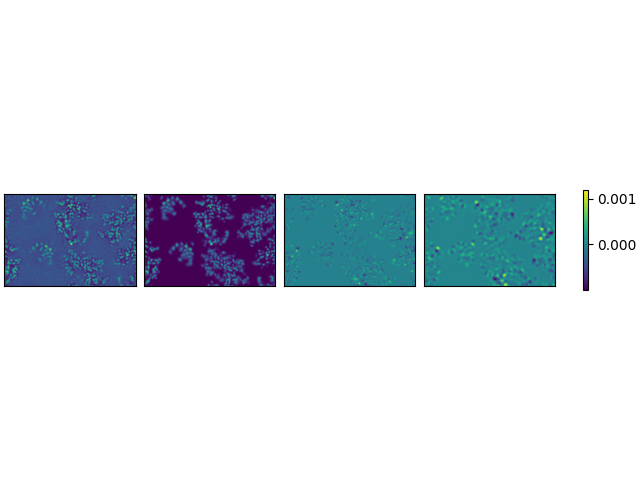

(<Figure size 640x480 with 5 Axes>,
 array([<Axes: >, <Axes: >, <Axes: >, <Axes: >], dtype=object))

In [16]:
rho_deltaT = density_lightT-density_darkT
step_size = np.array(rho_delta.shape)/ unit
print(step_size)
sigma = np.mean(step_size) * 1.75
dog_filterT = ndimage.gaussian_laplace(rho_delta, sigma=sigma)
# _ = slice_3d(density_darkT)
# _ = slice_3d(rho_deltaT)
# _ = slice_3d(dog_filterT)
panels_3d([rho_dark,
           density_darkT,
          rho_deltaT,
          dog_filterT,])

# rho_delta[np.abs(rho_delta)<1e-5] = 0
# _ = slice_3d(rho_delta)

# Creating Masks

## Calculating DoG Filter on real data

In [10]:
dark_struc = gemmi.read_structure(pdbloc_dark)

unit = np.array((
    dark_struc.cell.a,
    dark_struc.cell.b,
    dark_struc.cell.c
))


dark_struc.cell

<gemmi.UnitCell(70.2, 117.76, 170.47, 90, 90, 90)>

In [11]:
from scipy import ndimage

step_size = np.array(rho_delta_real.shape)/ unit
sigma = np.mean(step_size) * 1.75

dog_real_data = ndimage.gaussian_laplace(rho_delta_real, sigma=sigma)


In [158]:
print(np.nanmax(np.real(np.imag(rho_dark))))
%matplotlib widget
dog_real_data_v1 = ndimage.gaussian_laplace(rho_delta_real, sigma=sigma)
dog_real_data_v2 = ndimage.gaussian_laplace( rho_light- rho_dark, sigma=sigma)


2.1062372083723652e-17


interactive(children=(IntSlider(value=90, description='f0', max=179), Output()), _dom_classes=('widget-interac…

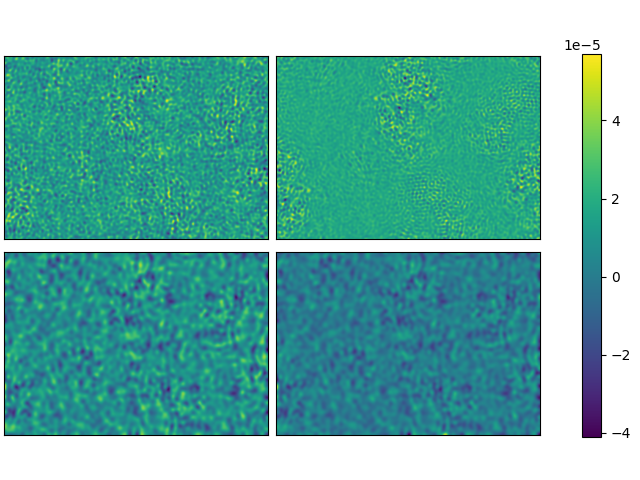

(<Figure size 640x480 with 5 Axes>,
 array([[<Axes: >, <Axes: >],
        [<Axes: >, <Axes: >]], dtype=object))

In [13]:
from output_eval import panels_3d
panels_3d([
            np.real(rho_delta_real),
            np.real( rho_light - rho_dark),
            np.real(dog_real_data_v1),
            np.real(dog_real_data_v2)
        ],figkwargs={'nrows':2,'ncols':2})

## Extracting Regions of Interest from DoG

In [17]:
from scipy import ndimage
def periodic_label_3d1(label_image):
    for dim in range(label_image.ndim):
        for idx_1 in range(label_image.shape[dim]):
            for idx_2 in range(label_image.shape[(dim+1)%3]):
                first = tuple(np.roll((idx_1,idx_2,0),dim))
                last = tuple(np.roll((idx_1,idx_2,-1),dim))
                if label_image[first] > 0 and label_image[last] > 0:
                    label_image[label_image == label_image[last]] = label_image[first]
    return label_image

def periodic_label_3d(label_image):
    from collections import defaultdict

    class UnionFind:
        def __init__(self):
            self.parent = {}

        def find(self, x):
            root = x
            while self.parent.get(root, root) != root:
                root = self.parent[root]
            while x != root:
                self.parent[x], x = root, self.parent[x]
            return root

        def union(self, x, y):
            self.parent[self.find(x)] = self.find(y)

        def relabel(self, array):
            mapping = {label: self.find(label) for label in np.unique(array) if label > 0}
            out = array.copy()
            for old, new in mapping.items():
                if old != new:
                    out[array == old] = new
            return out

    uf = UnionFind()
    shape = label_image.shape

    for dim in range(3):
        axis1 = (dim + 1) % 3
        axis2 = (dim + 2) % 3

        for i in range(shape[axis1]):
            for j in range(shape[axis2]):
                idx_first = [0, 0, 0]
                idx_last  = [0, 0, 0]

                idx_first[dim] = 0
                idx_last[dim] = shape[dim] - 1

                idx_first[axis1] = i
                idx_last[axis1] = i

                idx_first[axis2] = j
                idx_last[axis2] = j

                a = label_image[tuple(idx_first)]
                b = label_image[tuple(idx_last)]

                if a > 0 and b > 0 and a != b:
                    uf.union(a, b)

    return uf.relabel(label_image)


def pick_largest(
    result,
    thresh_fac,
    nth_val = 70,
):
    idcs_flat = np.argpartition(result.flatten(),-nth_val)[-nth_val:]
    idcs=np.unravel_index(idcs_flat,result.shape)
    thresh = np.min(result[idcs])*thresh_fac
    mask_dog = (result) > thresh
    labeled_dog, total_num = ndimage.label(mask_dog)
    labeled_dog = periodic_label_3d1( labeled_dog )
    # labeled_dog =label_periodic_3d_consistent(result, structure)

    
    
        # np.unique(labeled_dog, return_counts=True)
    idcs_labels = {}
    for idx in np.array(idcs).T:
        label = labeled_dog[tuple(idx)]
        if label not in idcs_labels.keys():
            size = np.sum(labeled_dog == label)
            idcs_labels[label] = size
    print(thresh,        idcs_labels)
    new_mask = np.zeros_like(labeled_dog)
    for key in     idcs_labels.keys():
        new_mask += labeled_dog==key
    return new_mask

def pick_largest2(
    result,
    thresh_fac,
    nth_val = 70,
):   
    new_mask = pick_largest(
        result,
        thresh_fac,
        nth_val = nth_val,
    )
    slice_3d(new_mask)
    new_mask_shift = pick_largest(
        np.fft.fftshift(result),
        thresh_fac,
        nth_val = nth_val,
    )
    slice_3d(new_mask_shift)
    return np.array(np.logical_or(new_mask, np.fft.ifftshift(new_mask_shift)),int)

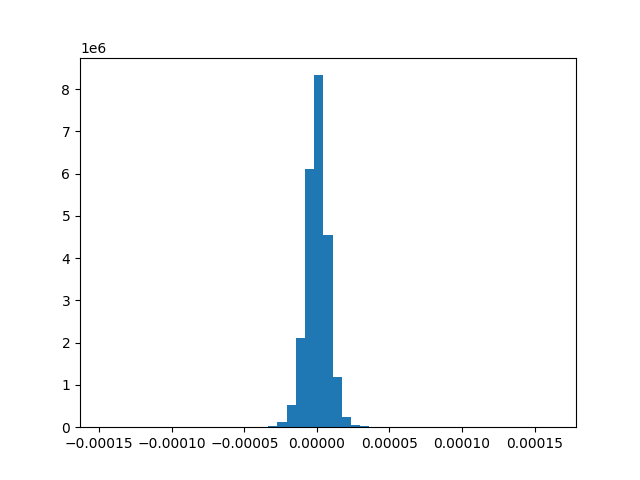

In [18]:
bins= np.linspace(np.min(dog_real_data_v2),np.max(dog_real_data_v2),50)
plt.figure()
_ = plt.hist(dog_real_data_v2.flatten(),bins=bins)


In [19]:
thresh_pos = 0.35
thresh_neg = 0.5
# thresh_pos = 2e-1
# thresh_neg = 2e-1
def calculate_dog_filter_mask_v1(delta_of_rho, sigma, thresh_pos, thresh_neg, detailed=False):
    dog_filter       = ndimage.gaussian_laplace( delta_of_rho, sigma=sigma)
    dog_filter_shift = ndimage.gaussian_laplace(np.fft.fftshift( delta_of_rho), sigma=sigma)
    
    mask_pos = pick_largest(       dog_filter       , thresh_fac=thresh_pos ) 
    mask_pos_shift = pick_largest( dog_filter_shift , thresh_fac=thresh_pos ) 
    mask_pos = mask_pos + np.fft.ifftshift(mask_pos_shift)
    
    mask_neg = pick_largest(      -dog_filter       , thresh_fac=thresh_neg ) 
    mask_neg_shift = pick_largest(-dog_filter_shift , thresh_fac=thresh_neg ) 
    mask_neg = mask_neg + np.fft.ifftshift(mask_neg_shift) 
    
    
    if detailed:
        return mask_pos, mask_neg, dog_filter, dog_filter_shift
    
    mask_comb = (mask_pos+mask_neg)>0
    return mask_comb

def undo_3d_tiling(mask, target_shape, lob_off):
    mask_comb = np.zeros((mask.shape[0], mask.shape[1],target_shape[2]))
    mask_comb[...,lob_off[2]:] +=mask[...,:target_shape[2]-lob_off[2]]
    mask_comb[...,:-lob_off[2]]+=mask[...,target_shape[2]-lob_off[2]:]

    mask_comb2 = np.zeros((mask.shape[0], target_shape[1],target_shape[2]))
    mask_comb2[:,lob_off[1]:,:] +=mask_comb[:,:target_shape[1]-lob_off[1],:]
    mask_comb2[:,:-lob_off[1],:]+=mask_comb[...,target_shape[1]-lob_off[1]:,:]

    mask_comb3 = np.zeros((target_shape))
    mask_comb3[lob_off[0]:,...] +=mask_comb2[:target_shape[0]-lob_off[0],...]
    mask_comb3[:-lob_off[0],...]+=mask_comb2[target_shape[0]-lob_off[0]:,...]
    
    return mask_comb3


def calculate_dog_filter_mask_v2(delta_of_rho, sigma, thresh_pos, thresh_neg, nth_val,
                                 target_shape, detailed=False):
    delta_rho_tiled = np.tile(delta_of_rho,(2,2,2))
    dog_filter       = ndimage.gaussian_laplace( delta_rho_tiled, sigma=sigma,)
    
    print('dogged')
   
    lob_off = target_shape//3


    slc = tuple(slice(lob,shp*2-lob) for lob,shp in zip(lob_off,target_shape))
    mask_pos = pick_largest(       dog_filter[slc]     , thresh_fac=thresh_pos,nth_val=nth_val ) 
    mask_neg = pick_largest(      -dog_filter[slc]     , thresh_fac=thresh_neg,nth_val=nth_val ) 

    mask_pos_comb = undo_3d_tiling(mask_pos, target_shape, lob_off)
    mask_pos_comb = np.array(mask_pos_comb>0,float)
    mask_neg_comb = undo_3d_tiling(mask_neg, target_shape, lob_off)
    mask_neg_comb = np.array(mask_neg_comb>0,float)
    if detailed:
        return mask_pos_comb, mask_neg_comb, dog_filter
    mask_comb = (mask_pos_comb + mask_neg_comb)>0

    return mask_comb
    

In [20]:
nth_val = 40*2**3
rho_shape = np.array(rho_light.shape)
mask_pos_real, mask_neg_real, dog_filter_real = calculate_dog_filter_mask_v2(np.real(rho_light-rho_dark), 
                                                                             sigma, thresh_pos, thresh_neg,
                                                                             nth_val, rho_shape, detailed=True)
mask_dog_real = mask_pos_real+mask_neg_real

dogged
2.0993028683250776e-05 {458: 916, 567: 916, 568: 916, 1278: 916, 1269: 816, 1279: 916, 640: 547, 639: 547, 426: 547, 1117: 700, 1384: 547, 38: 355, 4: 355, 1112: 916, 1814: 279, 1268: 816, 37: 355, 1379: 547, 1076: 547, 1385: 547, 1067: 547, 1380: 547, 5: 355}
2.3072807789160403e-05 {45: 407, 1177: 407, 1171: 407, 1172: 407, 1453: 407, 326: 407, 560: 407, 49: 407, 1176: 407, 824: 407, 44: 407, 561: 407, 839: 407, 50: 407}


interactive(children=(IntSlider(value=0, description='f0', max=179), Output()), _dom_classes=('widget-interact…

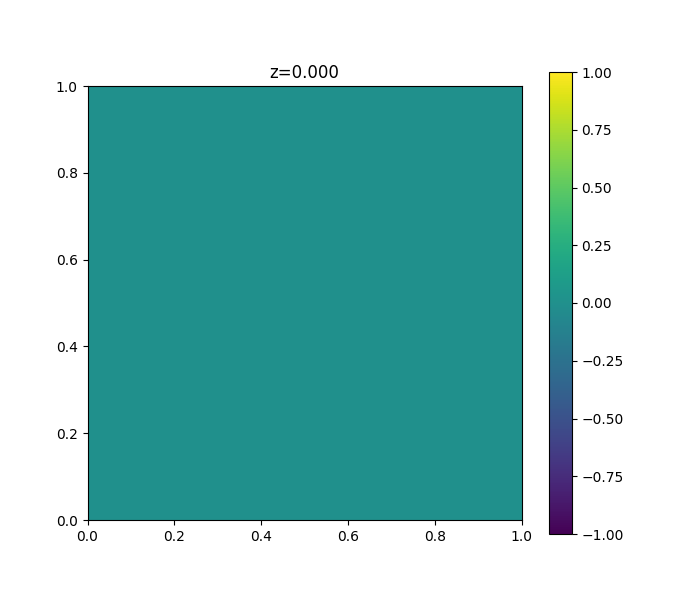

In [21]:
_ = slice_3d(mask_pos_real-mask_neg_real,imkwargs={'vmin':-1,'vmax':1})

In [22]:
# densities, neg_sum = marius(f_xtrs, mask_comb)



In [24]:
rho_delta_xtr = density_lightT-density_darkT
nth_val = 40*2**3
mask_pos_xtr, mask_neg_xtr, dog_filter_xtr = calculate_dog_filter_mask_v2(rho_delta_xtr, sigma, thresh_pos, thresh_neg,
                                                                          nth_val, rho_shape, detailed=True)
mask_dog_xtr = mask_pos_xtr+ mask_neg_xtr

dogged
0.00043308753183988417 {249: 940, 277: 940, 255: 940, 1734: 940, 1733: 940, 920: 836, 949: 836, 254: 836, 966: 836, 248: 836, 938: 940, 943: 940, 1750: 836, 919: 940, 1704: 836, 948: 836, 937: 940, 1710: 836, 278: 940, 944: 940, 1749: 836, 967: 836, 294: 836, 1711: 940, 293: 836, 1705: 940, 4: 561, 1496: 759, 1199: 759, 504: 759, 1960: 472, 3: 561, 1485: 759, 1495: 759, 727: 759, 50: 561, 1484: 759, 1195: 759, 51: 561, 726: 759}
0.0006085653616385465 {316: 548, 315: 548, 317: 548, 573: 548, 381: 548, 65: 548, 572: 548, 66: 548, 319: 766, 379: 766, 69: 766, 321: 766, 314: 548, 125: 766, 632: 766, 318: 766, 636: 760, 576: 766, 575: 766, 634: 548, 322: 766, 129: 760, 123: 548, 68: 766, 127: 548, 630: 548, 623: 564, 320: 564, 624: 564, 577: 564, 70: 564, 117: 564, 116: 564, 369: 564, 574: 564, 377: 564, 67: 564, 376: 564, 370: 564}


In [159]:
_ = slice_3d(mask_pos_xtr- mask_neg_xtr, imkwargs={'vmin':-1,'vmax':1})

In [ ]:
## Pseudo Z-score Mask

In [23]:
perc_size = 1e-4
perc_size = 4e-3
perc_high = np.percentile(rho_delta,100-perc_size)
perc_low = np.percentile(rho_delta,perc_size)
print(perc_low, perc_high)
mask_truth = np.logical_or(rho_delta>perc_high, rho_delta<perc_low)
mask_truth = np.logical_or(rho_delta>perc_high, rho_delta<perc_low)

-0.07670372393144184 0.08115989803322307


## Imported Masks

In [161]:
from scipy.ndimage import zoom

mask_loc = "../photolyase_masks/hand_crafted_mask.ccp4"
mask_loc_sphere = "../photolyase_masks/photolyase_TT_chainA_spherical_mask.ccp4"
mask_loc_handcraft = "../photolyase_masks/photolyase_chainA_spherical_masks.ccp4"
                                         # "photolyase_chainA_spherical_mask.ccp4"
def ccp4_to_mask(mask_loc, target_shape):
    mask_map = gemmi.read_ccp4_map(mask_loc)
    mask_map = np.array(mask_map.grid)
    new_shape = np.array(target_shape)/np.array(mask_map.shape)
    
    print(new_shape)
    ball_of_truth_rescaled = zoom(mask_map,new_shape)
    mask = ball_of_truth_rescaled>0.2
    mask = mask[::-1,::-1,::-1] # ccp4 convention is opposite mtz convention?
    return mask
mask_ball = ccp4_to_mask(mask_loc_sphere, rho_delta_xtr.shape)
mask_hand_picked = ccp4_to_mask(mask_loc_handcraft, rho_delta_xtr.shape)

[1.66666667 1.66666667 1.6875    ]


KeyboardInterrupt: 

## Overview over masks

interactive(children=(IntSlider(value=0, description='f0', max=179), Output()), _dom_classes=('widget-interact…

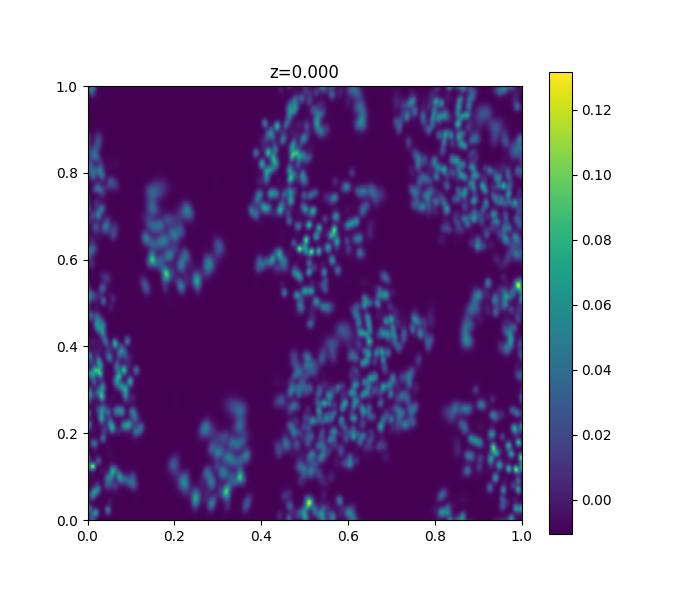

In [121]:
# _=slice_3d(dog_filter_real+np.tile(mask_ball,(2,2,2))*np.mean(np.abs(dog_filter_real)))
# _=slice_3d(rho_delta_xtr+mask_ball*np.mean(np.abs(rho_delta_xtr))*2)


# ds_dark = rs.read_mtz(dataloc_dark)
# ds_dark["sf_dark"] = ds_comb.to_structurefactor(dark_f, dark_phi)
# f_dark = ds_dark.to_reciprocal_grid( "sf_dark")
# density_dark = np.real(np.fft.ifftn(f_dark))


density_darkT
_=slice_3d(density_darkT+mask_hand_picked*np.mean(np.abs(density_darkT))*2)

interactive(children=(IntSlider(value=180, description='f0', max=359), Output()), _dom_classes=('widget-intera…

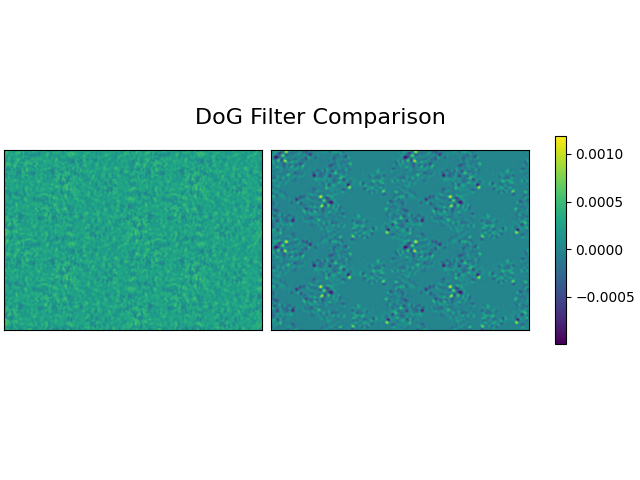

interactive(children=(IntSlider(value=90, description='f0', max=179), Output()), _dom_classes=('widget-interac…

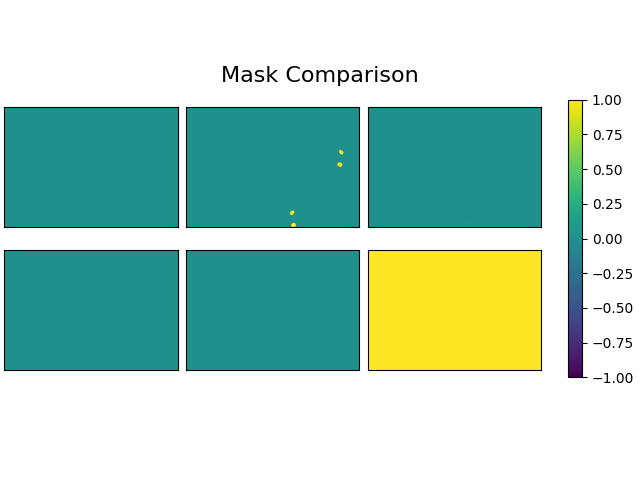

(<Figure size 640x480 with 7 Axes>,
 array([[<Axes: >, <Axes: >, <Axes: >],
        [<Axes: >, <Axes: >, <Axes: >]], dtype=object))

In [123]:
panels_3d([dog_filter_real, dog_filter_xtr], title="DoG Filter Comparison")
masks = [mask_dog_real, mask_dog_xtr, mask_truth, mask_ball, mask_hand_picked, np.ones_like(mask_ball)]
titles_mask = [
    "DoG (Measurement)", 
    "DoG (PDB deposited)",  
    "largest and smallest values \n(0.01%) (PDB deposited)",
     "Ball of Interest",
     "Hand picked Mask",
     "No Mask"
]
panels_3d(masks, title="Mask Comparison", figkwargs={'nrows':2,"ncols":3},imkwargs={'vmin':-1,'vmax':1})


# Occupancy determination attempts

In [128]:
import gc
gc.collect()

7274

In [44]:
dens_xtrs = [np.fft.ifftn(f_xtr).real for f_xtr in f_xtrs]

## Negative Sum Explosion

In [124]:
from occupancy import negsum_explode
from plotting3d import *
neg_sums = []
for mask in masks:
    neg_sum = negsum_explode(dens_xtrs, np.array(mask,bool) )
    neg_sums.append(neg_sum)

n_largest = 3
alpha_invs = 2/alphas

In [ ]:
from meteor import rsmap

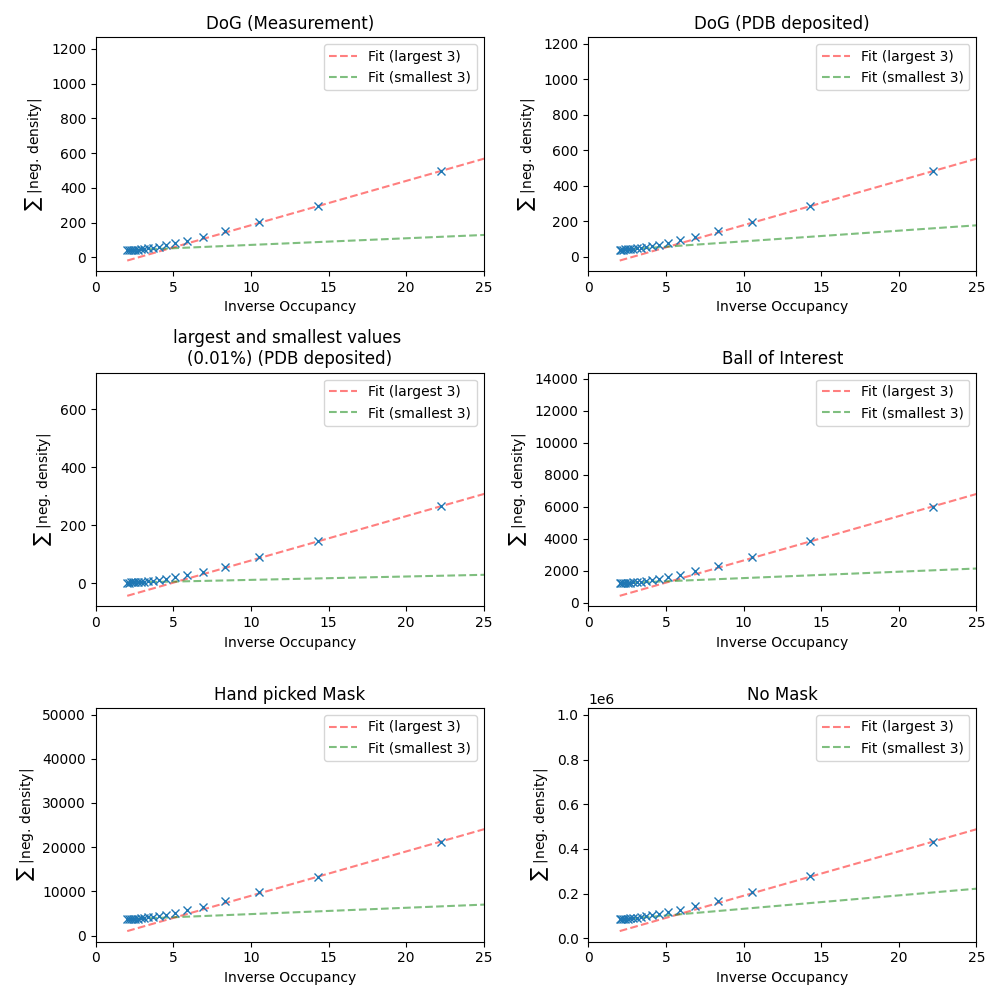

In [126]:
from plotting3d import add_fit
n_largest = 3
alpha_invs = 2/alphas
fig, axs = plt.subplots(3,2, figsize=(10,10),tight_layout=True)
for ii,neg_sum in enumerate(neg_sums):
    ax = axs.flat[ii]
    if n_largest:
        add_fit(neg_sum, alpha_invs, n_largest, ax=ax)

    ax.plot(alpha_invs, neg_sum * -1, "x")  # label="Datapoint")
    ax.set_title(titles_mask[ii])
    ax.legend()
    ax.set_xlabel("Inverse Occupancy")
    ax.set_ylabel(r"$\sum$ $|$neg. density$|$")
    ax.set_xlim(0,25)
# plt.ylim(0,300)
# plt.title(title)

## Histogram Method

### Histogram different masks

In [127]:
from plotting3d import val_distributions
config = {"alpha": "?", "zoom_in":False}
%matplotlib inline
density_dark = rho_dark
bins = np.arange(-.5, .5, 0.002)
bins = np.arange(-.1, .2, 0.002)

from plotting3d import val_distributions3
def get_hists(dens_xtr, rho_dark, mask):
    dhists = []
    lhists = []
    wdists = []
    for ii,(alpha_xtr, dens_xtr) in enumerate(zip(alphas, dens_xtrs)):
        config["alpha_xtr"] = np.round(alpha_xtr,4)
        # dens_xtr = np.real(np.fft.ifftn(f_xtr))
        wasser_dist,  bin_centers, hist_dark, hist_light = val_distributions3(
            rho_dark,
            dens_xtr,
            mask.astype(bool),
            bins,
        )
        wdists.append(wasser_dist)
        lhists.append(hist_light)
        dhists.append(hist_dark)

    return dhists, lhists, wdists

In [128]:
def plot_hists(dhists, lhists, wdists):
    fig, axs = plt.subplots(5,4, figsize=(12,10),tight_layout=True)
    bin_width = bin_centers[1]-bin_centers[0]
    for ii,ax in enumerate(axs.flat):
        # ax = axs.flat[0]
        ax.bar(bin_centers,lhists[ii],alpha=0.5, label="Dark", width = bin_width)
        ax.bar(bin_centers,dhists[ii],alpha=0.5, label="Extrapol.", width = bin_width)
        ax.set_title(f"Alpha: {alphas[ii]:.2f} \n Wasserstein: {wdists[ii]:.4f}")
    ax.legend()
    return fig, axs

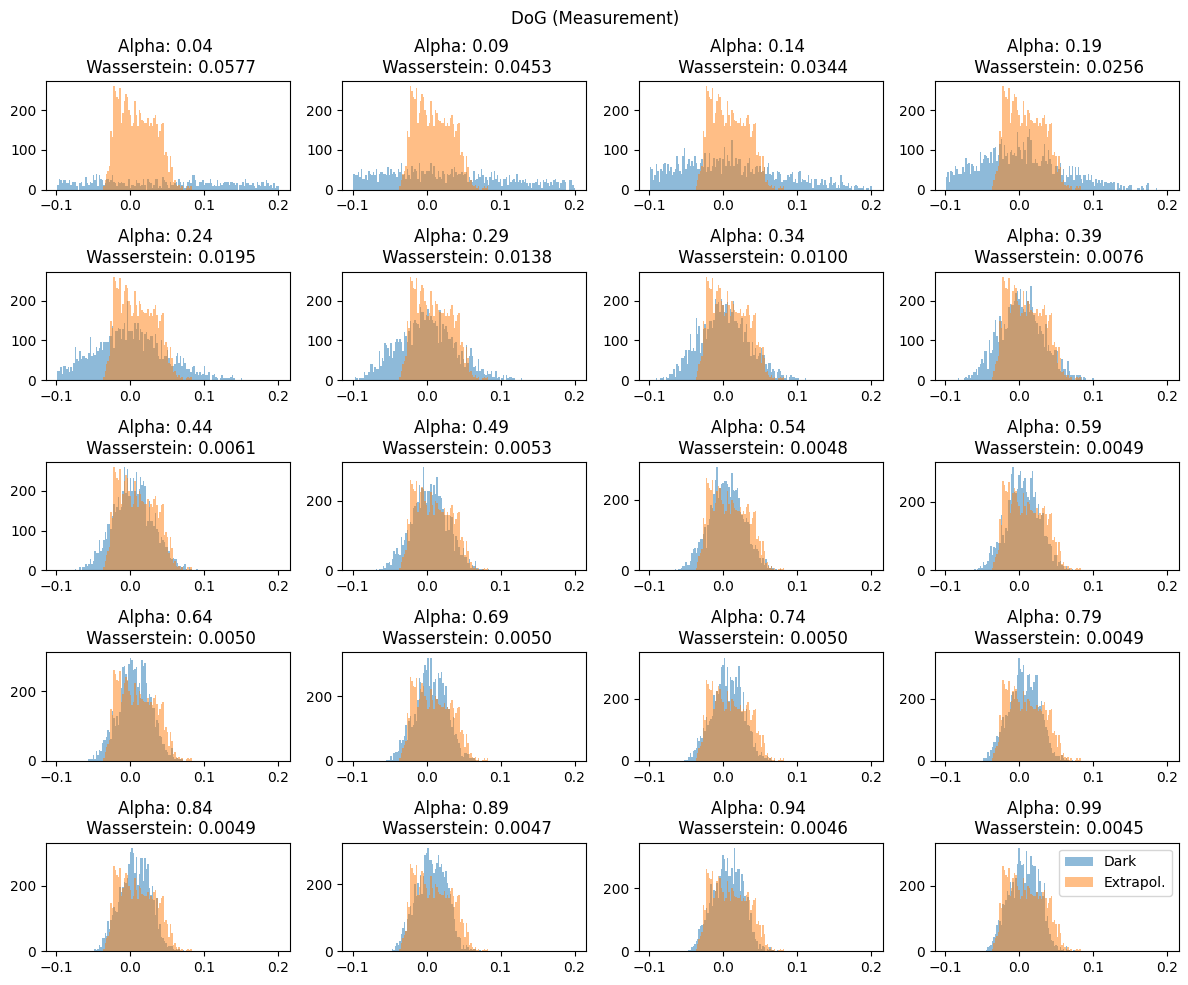

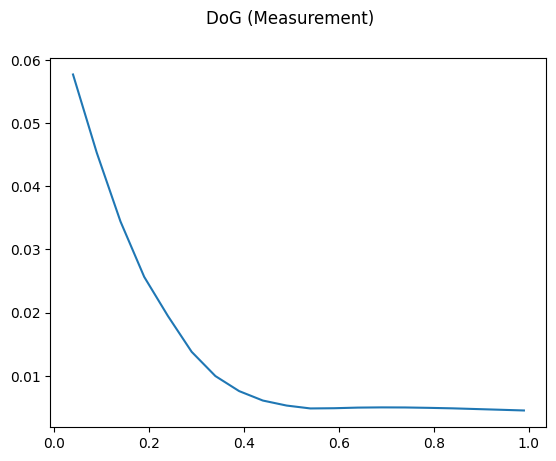

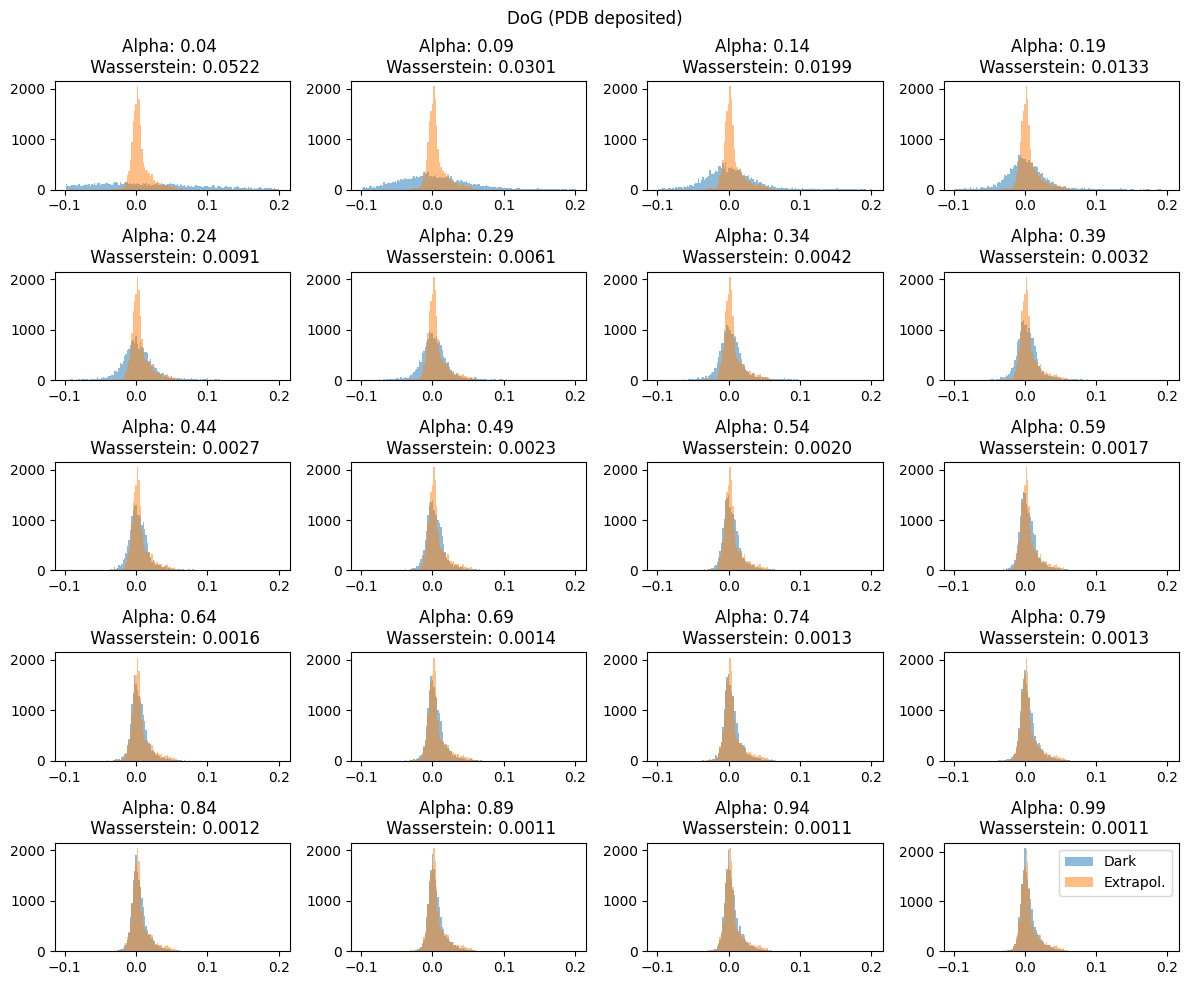

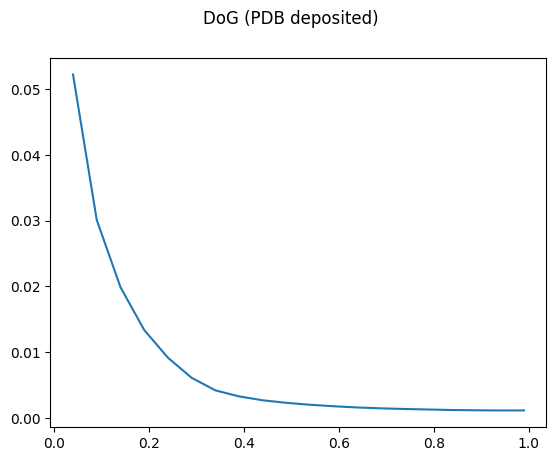

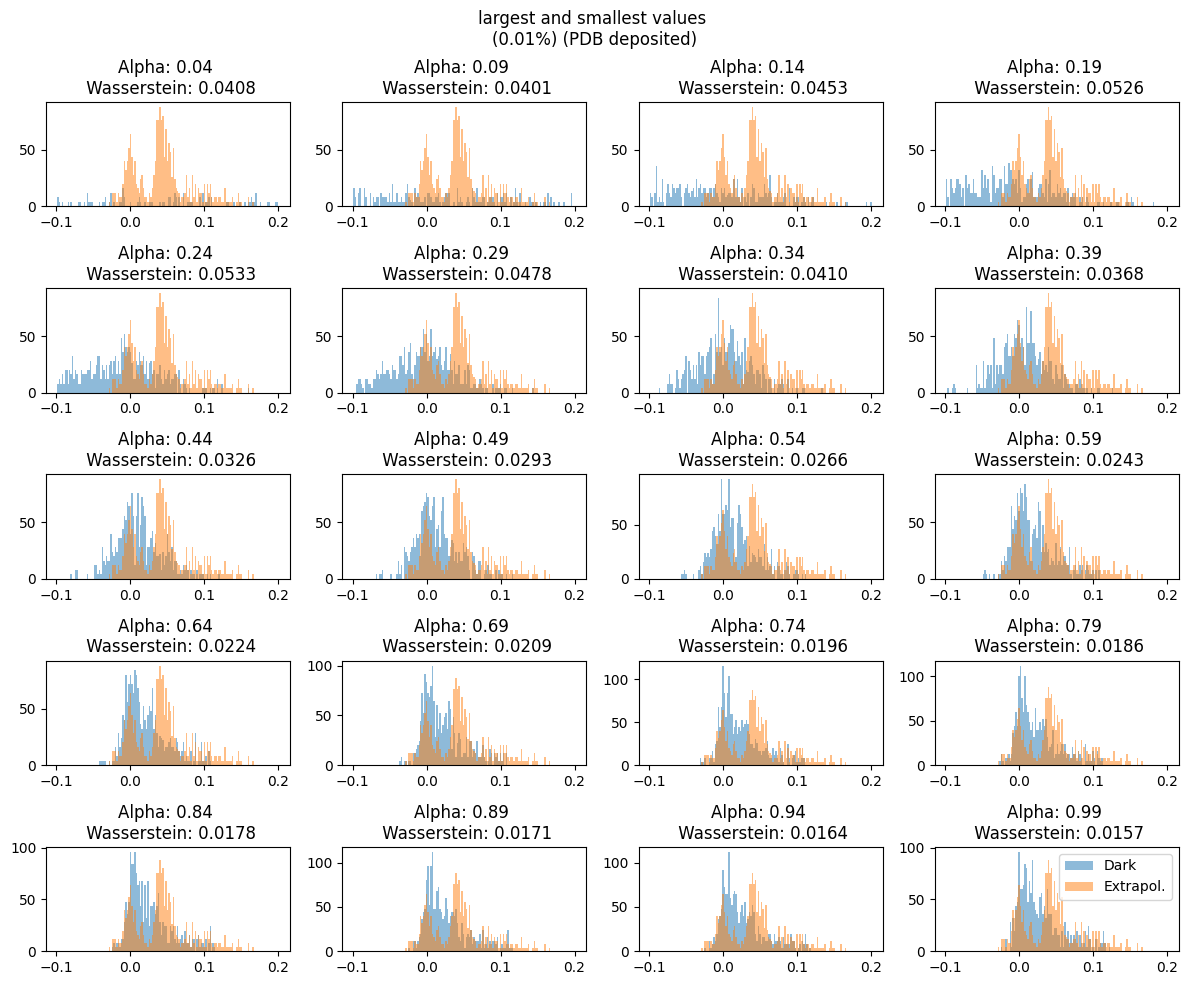

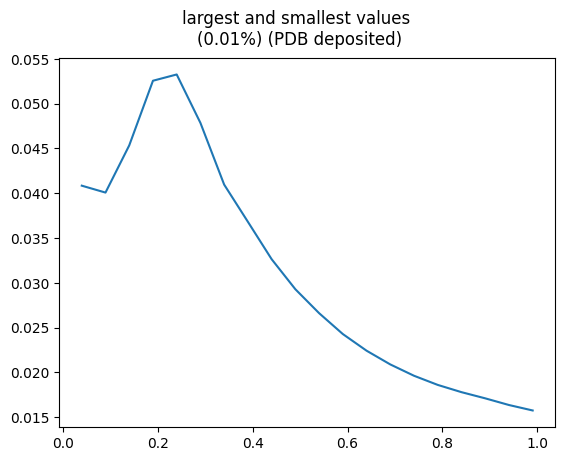

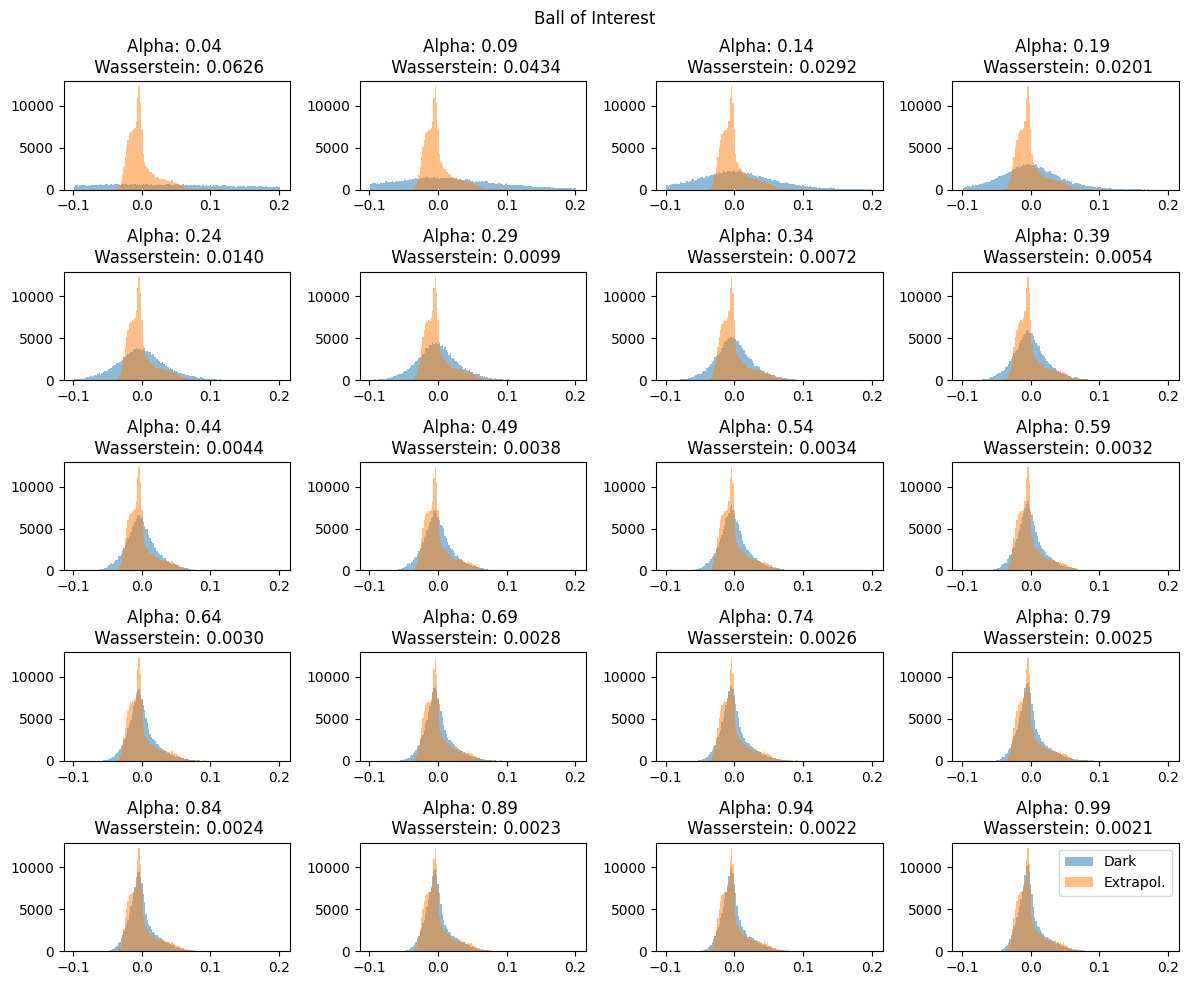

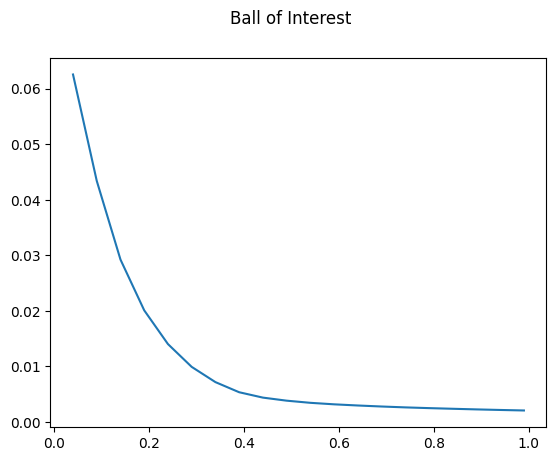

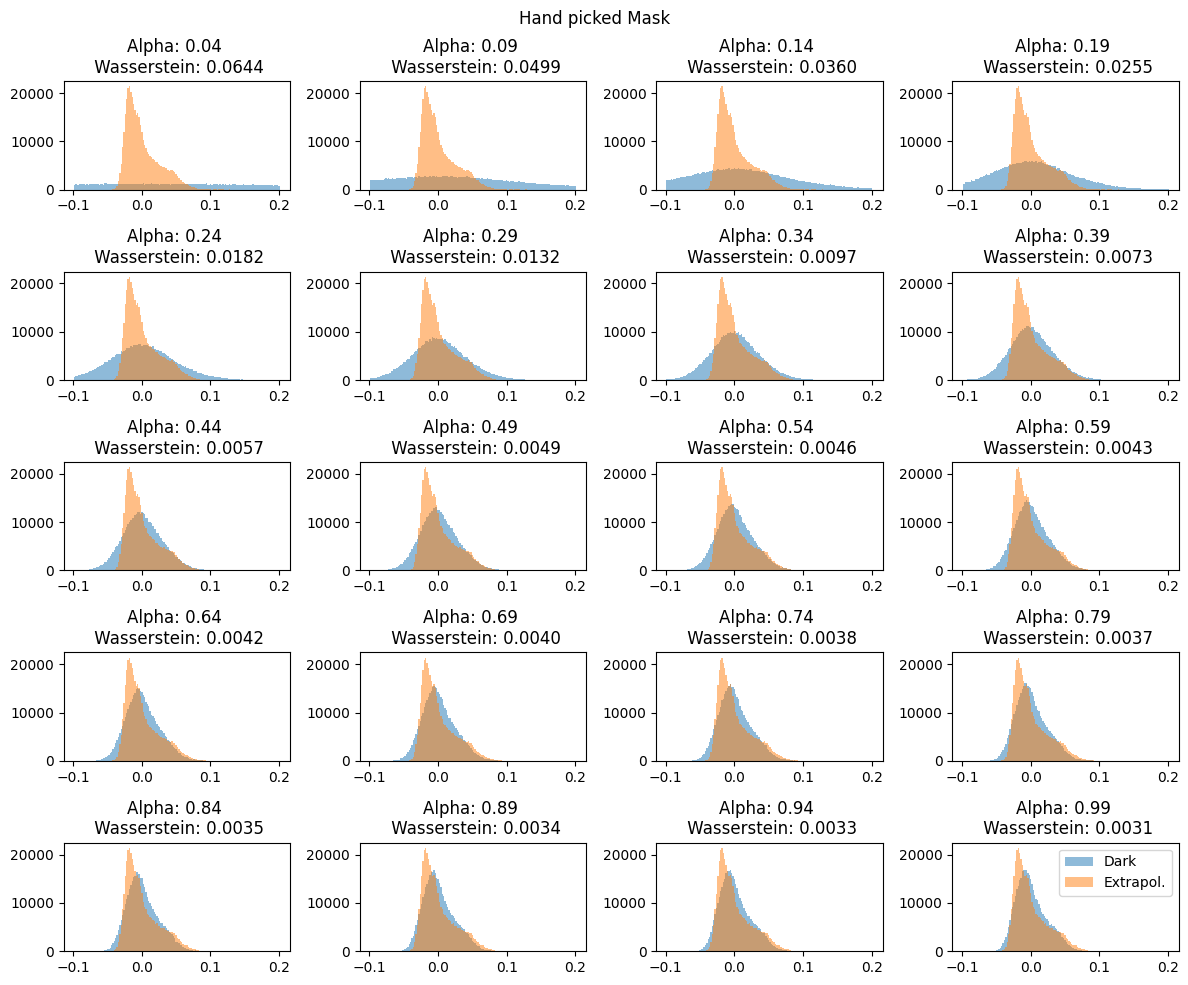

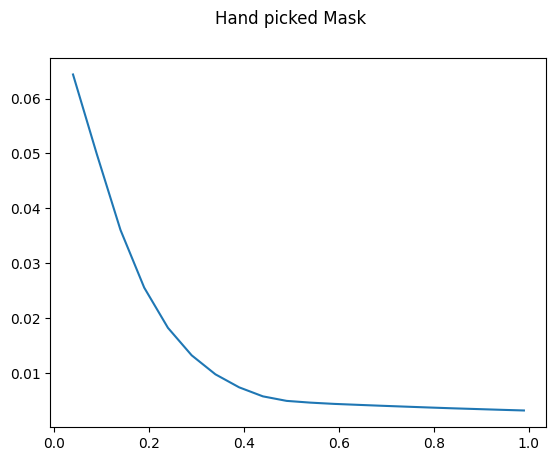

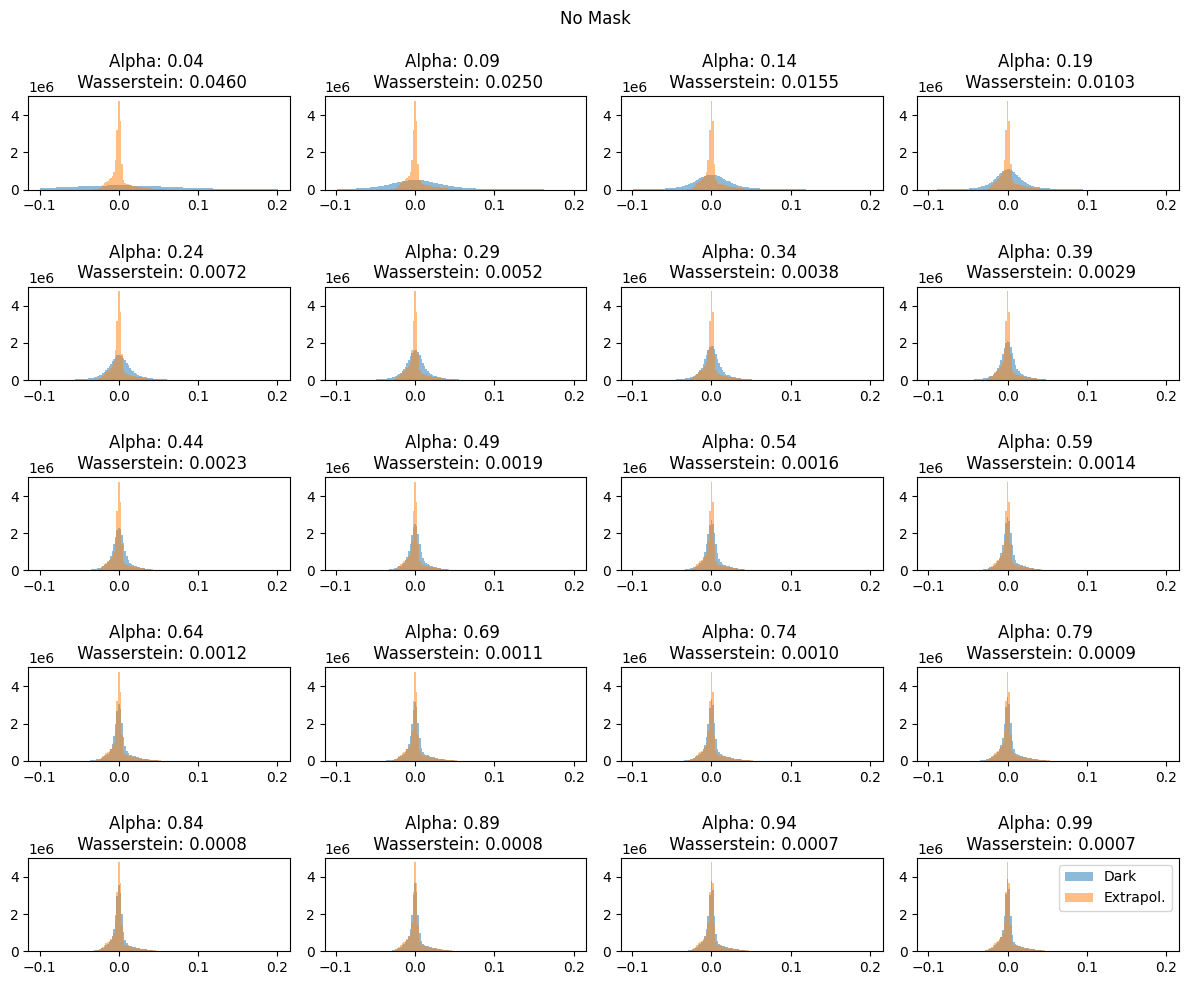

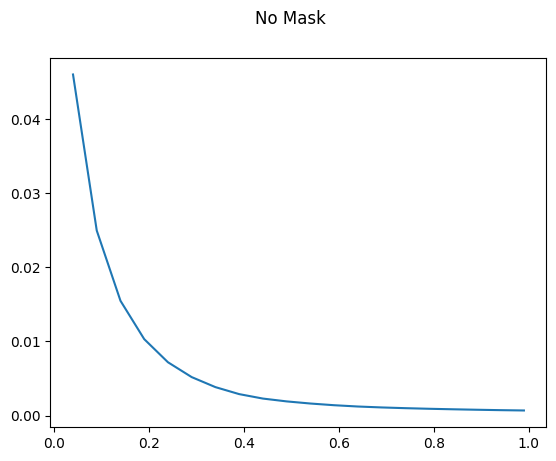

In [130]:
for ii, mask in enumerate(masks):
    dhists, lhists, wdists = get_hists(dens_xtr, rho_dark, mask)
    fig,ax1 = plot_hists(dhists, lhists, wdists)
    fig.suptitle(titles_mask[ii])
    fig, ax2 = plt.subplots() 
    fig.suptitle(titles_mask[ii])
    ax2.plot(alphas, wdists)
    plt.show()
    # combine_axes_equal(ax1, ax2)
    # break
    

### Histogram on phased result

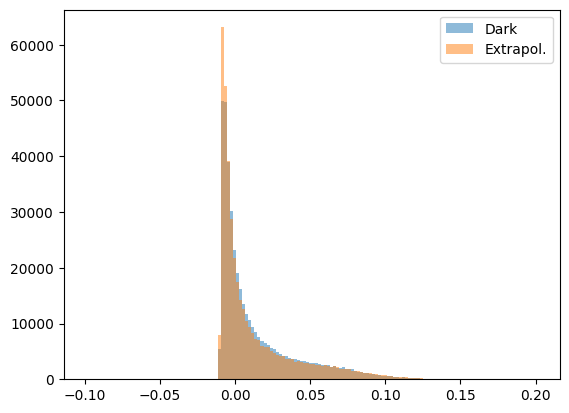

In [145]:
wassser_dist, bin_centers, hist_dark, hist_light = val_distributions3(density_darkT,density_lightT,mask_hand_picked, bins=bins,details=True)
barwidth = np.diff(bin_centers)[0]
%matplotlib inline
plt.figure()
plt.bar(bin_centers, hist_dark,width=barwidth, alpha=0.5, label="Dark")
plt.bar(bin_centers, hist_light,width=barwidth, alpha=0.5, label="Extrapol.")
plt.legend()
plt.show()

Axes(0.125,0.712609;0.133621x0.167391)
hist_dark max 52659.0
Axes(0.285345,0.712609;0.133621x0.167391)
hist_dark max 52659.0
Axes(0.44569,0.712609;0.133621x0.167391)
hist_dark max 52659.0
Axes(0.606034,0.712609;0.133621x0.167391)
hist_dark max 52659.0
Axes(0.766379,0.712609;0.133621x0.167391)
hist_dark max 52659.0
Axes(0.125,0.511739;0.133621x0.167391)
hist_dark max 52659.0
Axes(0.285345,0.511739;0.133621x0.167391)
hist_dark max 52659.0
Axes(0.44569,0.511739;0.133621x0.167391)
hist_dark max 52659.0
Axes(0.606034,0.511739;0.133621x0.167391)
hist_dark max 52659.0
Axes(0.766379,0.511739;0.133621x0.167391)
hist_dark max 52659.0
Axes(0.125,0.31087;0.133621x0.167391)
hist_dark max 52659.0
Axes(0.285345,0.31087;0.133621x0.167391)
hist_dark max 52659.0
Axes(0.44569,0.31087;0.133621x0.167391)
hist_dark max 52659.0
Axes(0.606034,0.31087;0.133621x0.167391)
hist_dark max 52659.0
Axes(0.766379,0.31087;0.133621x0.167391)
hist_dark max 52659.0
Axes(0.125,0.11;0.133621x0.167391)
hist_dark max 52659.0


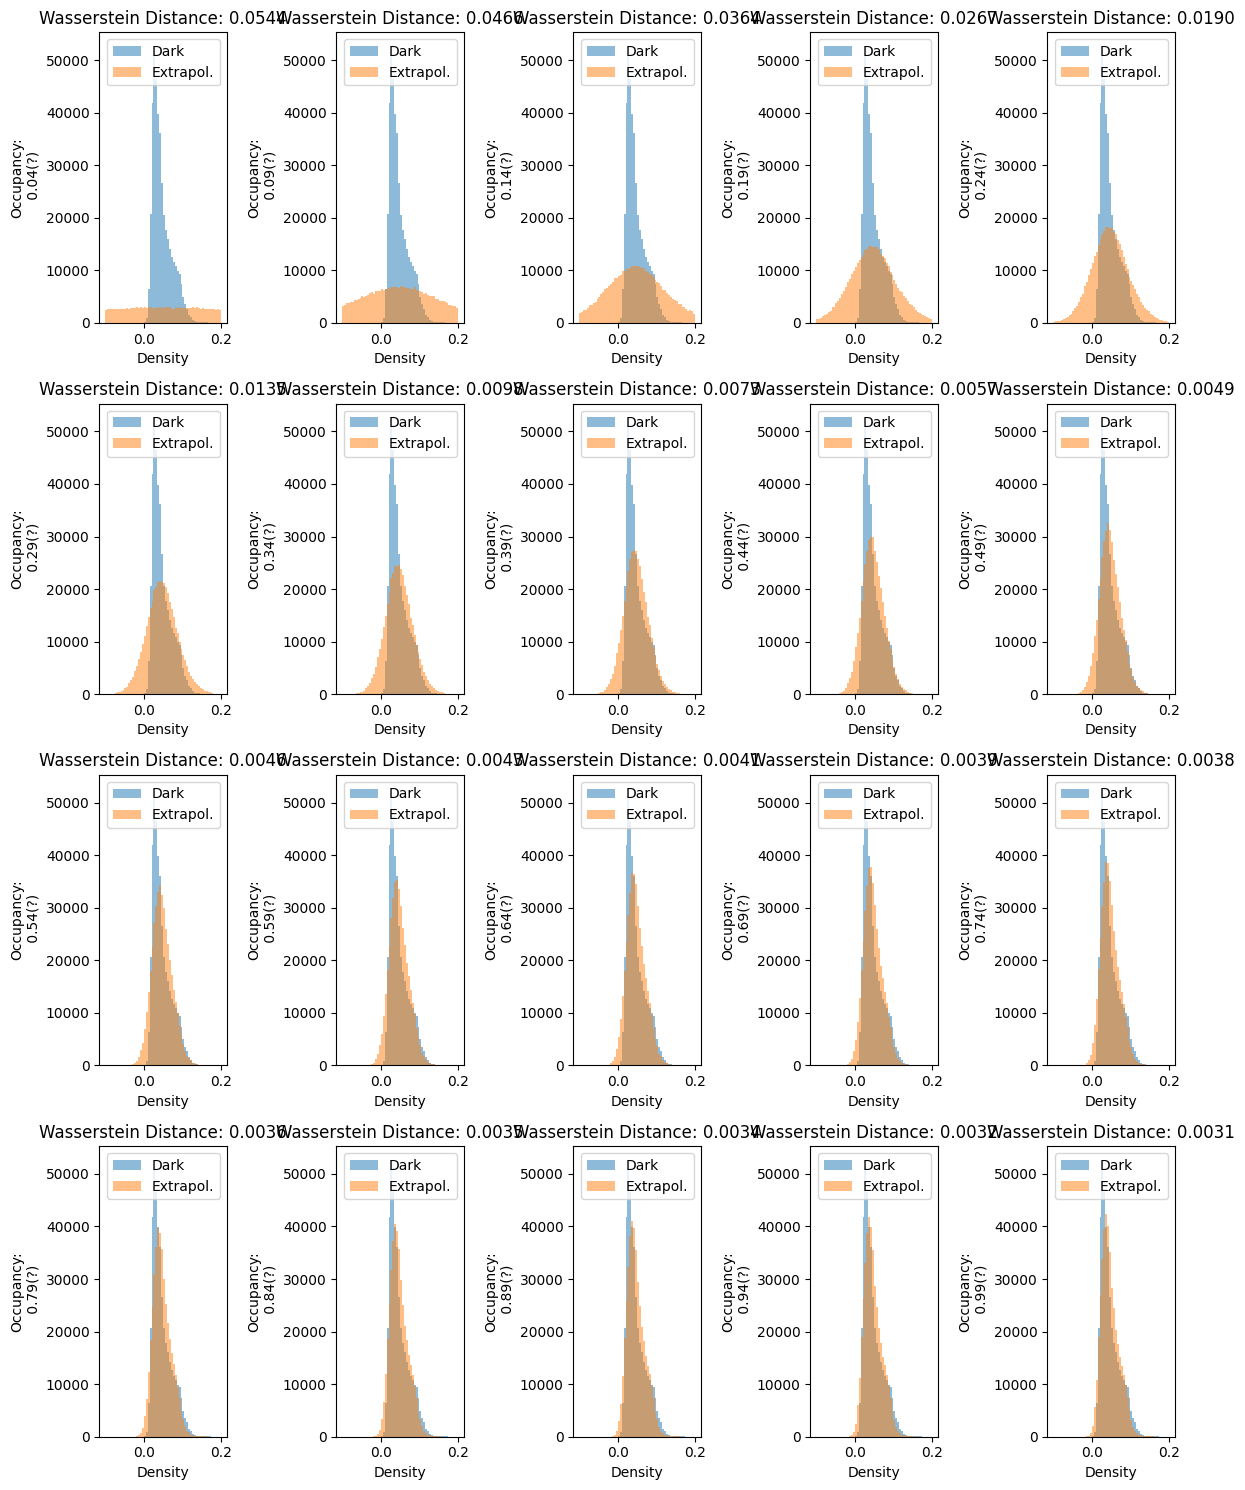

In [166]:
from plotting3d import val_distributions
config = {"alpha": "?", "zoom_in":False}
%matplotlib inline
# plt.figure()
density_dark = rho_dark
# dmin = np.min(density_dark)
# dmax = np.max(density_dark)
bins = np.arange(-.5, .5, 0.005)
bins = np.arange(-.1, .2, 0.005)

wdists = []
fig, axs = plt.subplots(4,5, figsize=(12,15),tight_layout=True)
for ii,(alpha_xtr, f_xtr) in enumerate(zip(alphas, f_xtrs_prime)):
    config["alpha_xtr"] = np.round(alpha_xtr,4)
    dens_xtr = np.real(np.fft.ifftn(f_xtr))
    wasser_dist = val_distributions2(
    rho_dark_prime,
        dens_xtr,
        mask_hand_picked,
        # ~np.isnan(mask_truth),
        bins,
        config,
        ax = axs.flat[ii]
    )
    wdists.append(wasser_dist)

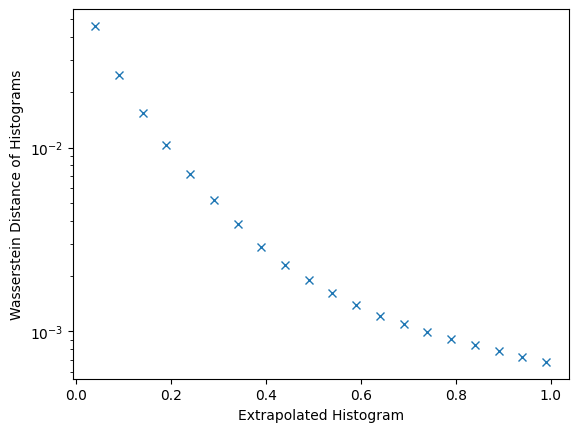

In [148]:
plt.figure()
plt.plot(alphas,wdists, "x")
plt.yscale("log")
plt.xlabel('Extrapolated Histogram')
plt.ylabel('Wasserstein Distance of Histograms')
plt.show()

# Exporting Data to coot

In [149]:
f_delta = ds_comb.to_reciprocal_grid( "sf_delta")
f_light = ds_comb.to_reciprocal_grid( "sf_light")
f_dark[np.isnan(f_dark)]=0
f_light[np.isnan(f_light)]=0
print(f_dark[0,0,0])

from occupancy import make_f_xtr
f_angle = np.angle(f_dark)
# f_light[0,0,0] = -dmin*2


0j


In [150]:
f_light[np.isnan(f_light)]=0
f_dark[np.isnan(f_dark)]=0
print(f_dark[0,0,0])


0j


In [151]:
rho_dark =( np.fft.ifftn(f_dark))
dmin = np.min(rho_dark)
print("minimum")
print(dmin)
dmin = np.min(rho_dark-dmin)
dmin = np.min(rho_dark)
print(dmin)
f_dark_prime= np.fft.fftn(rho_dark-dmin)

# f_dark_prime-f_dark
print(np.sum((np.abs(f_dark_prime-f_dark))>1))
print(np.max(np.abs(f_dark_prime-f_dark)))
print(np.unravel_index(np.argmax(np.abs(f_dark_prime-f_dark)), f_dark.shape))
print(f_dark[0,0,0])
print(f_dark_prime[0,0,0])
# slice_3d()

# f_dark.size, 


minimum
(-0.04672461656292347-3.8333239438877315e-18j)
(-0.04672461656292347-3.8333239438877315e-18j)
1
1089991.8551798787
(0, 0, 0)
0j
(1089991.8551798787+8.9423780963013e-11j)


In [152]:
dmin = np.min(rho_dark)

f_dark_prime= f_dark.copy()
f_light_prime= f_light.copy()
f_dark_prime[0,0,0] =  -rho_dark.size*dmin
f_light_prime[0,0,0] =  -rho_dark.size*dmin

f_xtrs_prime =  make_f_xtr(alphas, f_dark_prime, f_light_prime, f_angle,version=1)
rho_dark_prime = np.fft.ifftn(f_dark_prime).real

In [ ]:

arr = np.array(ds_dark.get_hkls())
np.max(arr, axis=0)

In [ ]:

dark_f="F-obs-filtered"
dark_phi="PHIF-model"
# ds_light = "PHIF-model"
light_f = "FMEAN"

ds_dark["sf_dark"] = ds_dark.to_structurefactor(dark_f, dark_phi)
ds_light["sf_light"] = ds_light.to_structurefactor("F", dark_phi)

f_dark = ds_comb.to_reciprocal_grid( "sf_dark")
f_light = ds_comb.to_reciprocal_grid( "sf_light")

f_dark[np.isnan(f_dark)]=0
f_light[np.isnan(f_light)]=0
rho_true_light = np.fft.ifftn(f_light)
rho_true_dark = np.fft.ifftn(f_dark)
write_mtz(rho_true_dark,"rho_true_dark_PL30.mtz")
write_mtz(rho_true_light,"rho_true_light_PL30.mtz")

In [80]:
alphas_show = np.array([0.08, 0.4, 0.55])
f_xtrs_show =  make_f_xtr(alphas_show, f_dark, f_light, f_angle,version=1)


In [85]:
title_extrapolated = [f"manual_xtr_PL30_{(alph*100):.0f}.mtz" for alph in alphas_show]
title_extrapolated

['manual_xtr_PL30_8.mtz', 'manual_xtr_PL30_40.mtz', 'manual_xtr_PL30_55.mtz']

In [131]:
from meteor import rsmap
%matplotlib widget
def write_mtz(data_array, fname, rsdf, hs_limit):
    print('did you check orientation')
    mapobj = rsmap.Map.from_3d_numpy_map(data_array, 
                                         spacegroup=rsdf.spacegroup,
                                         cell =rsdf.cell, 
                                         high_resolution_limit=hs_limit)
    plt.show()
    mapobj.write_mtz(fname)
    
# def write_mtz(datafile, name, rsdf, hs_limit):
#     mapobj = rsmap.Map.from_3d_numpy_map(np.fft.fftshift(datafile), spacegroup=19, cell =ds_comb.cell, high_resolution_limit=1.2)
#     mapobj.write_mtz(name)
    
# def write_mtz(datafile, name):
#     fg = gemmi.FloatGrid(*datafile.shape)
#     fg.spacegroup = ds_comb.spacegroup
#     fg.set_unit_cell(ds_comb.cell)
#     np.array(fg, copy=False)[:] = datafile
#     print(type(fg))
#     ccp4 = gemmi.Ccp4Map()
#     ccp4.grid = fg
#     # ccp4.update_header()
#     ccp4.write_ccp4_map(name)


    
for title, fxtr in zip(title_extrapolated,f_xtrs_show,):
    rho_xtr =np.real(np.fft.ifftn(fxtr))
    rho_xtr = rho_xtr[::-1,::-1,::-1]
    # write_mtz(rho_xtr, title,ds_comb,1.2) 

In [132]:
 plt.close('all')

In [ ]:
write_mtz(dog_filter_real, "dog_filter_real.mtz") 
write_mtz(dog_filter_xtr, "dog_filter_xtr.mtz") 


In [ ]:
write_mtz(mask_dog_real*0.1, "mask_dog_real.mtz") 
write_mtz(mask_dog_xtr*0.1, "mask_dog_xtr.mtz") 
